In [3]:
from google.colab import drive

# force_remount=True 옵션을 사용해 드라이브를 강제로 다시 마운트합니다.
# 이 방법은 기존 내용을 삭제하지 않고 안전하게 연결을 초기화합니다.
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
# 변경 내용 각주 추가 

In [5]:
### [1/7] 파이프라인 1단계: 프로젝트 설정 및 아키텍처 정의 (v6) ###

# === 0. 라이브러리 임포트 ===
import xgboost
import os
import pandas as pd
import numpy as np
import cv2
import matplotlib.pyplot as plt
from tqdm import tqdm
import joblib
from scipy.stats import pearsonr
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import MinMaxScaler
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from skimage.feature import graycomatrix, graycoprops
import smogn

print("✅ [1/7] 라이브러리 임포트 완료")


# === 1. 전역 설정 ===
BASE_DRIVE_PATH = "/content/drive/MyDrive"
# [수정] 새로운 결과물을 저장할 v6 폴더를 지정합니다.
OUTPUT_DIR = os.path.join(BASE_DRIVE_PATH, "solder_replication_output_v6")
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f" -> 모든 결과물은 다음 폴더에 저장됩니다: '{OUTPUT_DIR}'")


# === 2. 하이퍼파라미터 탐색 제어 스위치 ===
# [신설] True로 설정하면 GridSearchCV로 최적 파라미터를 다시 탐색하고,
#         False로 설정하면 아래에 정의된 최적 파라미터를 사용해 빠르게 학습합니다.
PERFORM_GRID_SEARCH = True
print(f" -> 하이퍼파라미터 탐색(GridSearchCV) 활성화: {PERFORM_GRID_SEARCH}")


# === 3. 고정 하이퍼파라미터 정의 ===
# PERFORM_GRID_SEARCH = False일 때 사용될 최적의 파라미터 값들입니다.
BEST_PARAMS_M11 = {
    'colsample_bytree': 1.0, 'gamma': 0, 'learning_rate': 0.05,
    'max_depth': 7, 'n_estimators': 400, 'reg_alpha': 0,
    'reg_lambda': 1.5, 'subsample': 0.8
}
BEST_PARAMS_M15 = {
    'colsample_bytree': 1.0, 'gamma': 0, 'learning_rate': 0.05,
    'max_depth': 8, 'n_estimators': 400, 'reg_alpha': 0,
    'reg_lambda': 1, 'subsample': 0.8
}


# === 4. 모델 및 데이터 아키텍처 정의 (변경 없음) ===
MODEL_DEFINITIONS = {
    'model_11': {
        'metadata_path': os.path.join(BASE_DRIVE_PATH, "metadata_model11.csv"),
        'image_path': os.path.join(BASE_DRIVE_PATH, "images_main"),
        'best_params': BEST_PARAMS_M11 # 각 모델에 맞는 파라미터 연결
    },
    'model_15': {
        'metadata_path': os.path.join(BASE_DRIVE_PATH, "metadata_model15.csv"),
        'image_path': os.path.join(BASE_DRIVE_PATH, "images_gull"),
        'best_params': BEST_PARAMS_M15 # 각 모델에 맞는 파라미터 연결
    }
}

# --- 데이터 처리 파라미터 (변경 없음) ---
RESIZE_SHAPE = (128, 128)
MIN_IMAGE_WIDTH = 10
MIN_IMAGE_HEIGHT = 10

print("--- ✅ [1/7] 프로젝트 설정 완료 ---")

✅ [1/7] 라이브러리 임포트 완료
 -> 모든 결과물은 다음 폴더에 저장됩니다: '/content/drive/MyDrive/solder_replication_output_v6'
 -> 하이퍼파라미터 탐색(GridSearchCV) 활성화: True
--- ✅ [1/7] 프로젝트 설정 완료 ---


In [6]:
### [2/7] 파이프라인 2단계: 핵심 특징 추출 함수 (최종본) ###

# === 보조 엔진: Region Covariance 계산 함수 (변경 없음) ===
def calculate_region_covariance(image):
    if image is None or image.size == 0: return np.full(15, 0.0)
    height, width, _ = image.shape
    y_coords, x_coords = np.mgrid[0:height, 0:width]
    pixels = np.vstack((x_coords.ravel(), y_coords.ravel(), image[:, :, 2].ravel(), image[:, :, 1].ravel(), image[:, :, 0].ravel())).T
    cov_matrix = np.cov(pixels.astype(float), rowvar=False)
    return cov_matrix[np.triu_indices(5)]

# === 메인 엔진: 최종 특징 추출 함수 ===
def extract_solder_features_final(image):
    """
    [최종 버전] '색상 전이 매트릭스'와 '매트릭스 비대칭' 특징을 포함하여
    총 53개의 특징을 추출합니다.
    """
    if image is None or image.size == 0:
        return None

    # --- 전처리: 이동 평균 필터 및 리사이즈 ---
    kernel_size = (3, 3)
    filtered_image = cv2.blur(image, kernel_size)
    img = cv2.resize(filtered_image, RESIZE_SHAPE)

    # --- 그룹 1 ~ 5: 기본 특징 42개 계산 ---
    # (기본 통계, GLCM, 색상 비율, Region Covariance 등)
    r_mean, g_mean, b_mean = np.mean(img, axis=(0, 1))[[2, 1, 0]]
    r_std, g_std, b_std = np.std(img, axis=(0, 1))[[2, 1, 0]]
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    s = np.mean(hsv[:, :, 1]) / 255.0
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    gray_mean, gray_std = np.mean(gray), np.std(gray)
    total = r_mean + g_mean + b_mean + 1e-6
    r_ratio, g_ratio, b_ratio = (r_mean/total, g_mean/total, b_mean/total)
    grad_r = np.mean(np.abs(np.diff(img[:, :, 2].astype(float), axis=1))) if img.shape[1] > 1 else 0.0
    grad_g = np.mean(np.abs(np.diff(img[:, :, 1].astype(float), axis=1))) if img.shape[1] > 1 else 0.0
    grad_b = np.mean(np.abs(np.diff(img[:, :, 0].astype(float), axis=1))) if img.shape[1] > 1 else 0.0
    edge = np.mean(cv2.Canny(gray, 50, 150)) / 255.0
    distances = [1, 3, 5]; angles = [0, np.pi/4, np.pi/2, 3*np.pi/4]
    glcm = graycomatrix(gray, distances=distances, angles=angles, levels=256, symmetric=True, normed=True)
    glcm_props = ['contrast', 'correlation', 'homogeneity', 'energy']
    glcm_features = {f'{prop}_{stat}': getattr(np, stat)(graycoprops(glcm, prop).ravel()) for prop in glcm_props for stat in ['mean', 'std']}
    lower_red1 = np.array([0, 100, 100]); upper_red1 = np.array([10, 255, 255])
    lower_red2 = np.array([170, 100, 100]); upper_red2 = np.array([180, 255, 255])
    red_mask = cv2.inRange(hsv, lower_red1, upper_red1) + cv2.inRange(hsv, lower_red2, upper_red2)
    red_val = np.sum(red_mask > 0) / (img.shape[0] * img.shape[1])
    lower_black = np.array([0, 0, 0]); upper_black = np.array([180, 255, 50])
    black_mask = cv2.inRange(hsv, lower_black, upper_black)
    black_val = np.sum(black_mask > 0) / (img.shape[0] * img.shape[1])
    rc_features = calculate_region_covariance(img)

    # --- 그룹 6: 색상 전이 횟수 매트릭스 (신규 추가, 9개) ---
    quantized_img = np.argmax(img, axis=2)
    transition_matrix = np.zeros((3, 3))
    # B=0, G=1, R=2 순서로 매트릭스 계산
    for i in range(3): # 기준 색상 (From)
        for j in range(3): # 타겟 색상 (To)
            from_mask = (quantized_img[:, :-1] == i)
            to_mask = (quantized_img[:, 1:] == j)
            transition_matrix[i, j] = np.sum(from_mask & to_mask)

    colors = ['B', 'G', 'R']
    transition_features = {}
    for i, from_c in enumerate(colors):
        for j, to_c in enumerate(colors):
            # BGR 순서에 맞춰서 R(2), G(1), B(0) 인덱스를 사용
            transition_features[f'trans_{from_c}_to_{to_c}'] = transition_matrix[i, j]

    # --- 그룹 7: 전이 매트릭스 기반 비대칭 특징 (신규 추가, 2개) ---
    lower_sum = np.tril(transition_matrix, k=-1).sum()
    upper_sum = np.triu(transition_matrix, k=1).sum()
    asymmetry_features = {
        'trans_matrix_lower_sum': lower_sum,
        'trans_matrix_upper_sum': upper_sum
    }

    # === 최종 특징 딕셔너리 조합 ===
    feature_dict = {
        "r_mean": r_mean, "g_mean": g_mean, "b_mean": b_mean, "r_std": r_std, "g_std": g_std, "b_std": b_std,
        "grad_r": grad_r, "grad_g": grad_g, "grad_b": grad_b, "r_ratio": r_ratio, "g_ratio": g_ratio, "b_ratio": b_ratio,
        "s": s, "gray_mean": gray_mean, "gray_std": gray_std,
        "edge": edge, "red": red_val, "black": black_val
    }
    feature_dict.update(glcm_features)
    for i, val in enumerate(rc_features):
        feature_dict[f'rc_{i}'] = val

    feature_dict.update(transition_features)
    feature_dict.update(asymmetry_features)

    return feature_dict

print("✅ [2/7] 최종 특징 추출 함수 정의 완료")

✅ [2/7] 최종 특징 추출 함수 정의 완료


In [7]:
### [3/7] 파이프라인 3단계: 데이터 팩토리 - 학습용 데이터셋 구축 (최종 단순화 버전) ###

def prepare_data_pipeline(
    model_definitions: dict,
    feature_extraction_func: callable,
    output_dir: str,
    force_rerun: bool = False
) -> dict:
    """
    [최종 단순화 버전] 모든 모델에 동일한 전처리 및 특징 추출을 적용합니다.
    """
    print("\\n--- 🚀 [3/7] 데이터 준비 및 특징 추출 파이프라인 시작 ---")

    # 1. 캐싱(Caching) 기능
    all_processed_dfs = {}
    all_cached = not force_rerun
    for model_name in model_definitions.keys():
        if not os.path.exists(os.path.join(output_dir, f"features_{model_name}.csv")):
            all_cached = False
            break

    if all_cached:
        print("✅ 모든 모델의 캐시 파일이 존재합니다. 파일에서 데이터를 즉시 로드합니다.")
        for model_name in model_definitions.keys():
            all_processed_dfs[model_name] = pd.read_csv(os.path.join(output_dir, f"features_{model_name}.csv"))
        print("--- ✅ [3/7] 데이터 준비 완료 (캐시 로드) ---")
        return all_processed_dfs

    print("⚠️  캐시 파일이 없거나 재실행이 요청되었습니다. 전체 특징 추출을 시작합니다. (시간 소요)")

    # 2. 마스터 메타데이터 생성
    master_df_list = []
    for model_name, props in model_definitions.items():
        try:
            df = pd.read_csv(props['metadata_path'])
            df['model_name'] = model_name
            df['image_base_path'] = props['image_path']
            master_df_list.append(df)
        except FileNotFoundError:
            print(f"경고: 메타데이터 파일을 찾을 수 없습니다 - {props['metadata_path']}")

    if not master_df_list:
        print("오류: 로드할 수 있는 메타데이터 파일이 없습니다. 프로세스를 중단합니다.")
        return None

    master_df = pd.concat(master_df_list, ignore_index=True)
    master_df.rename(columns={'probability': 'hacarus_prob'}, inplace=True)

    # 3. 메인 처리 루프
    extracted_data = []
    for _, row in tqdm(master_df.iterrows(), total=len(master_df), desc="이미지 처리 및 특징 추출"):
        image_path = os.path.join(row['image_base_path'], row['filename'])
        if not os.path.exists(image_path): continue

        original_image = cv2.imread(image_path)
        if original_image is None: continue

        # ROI 잘라내기 (CSV 파일에 roi_x, roi_y, roi_w, roi_h 컬럼이 있다고 가정)
        try:
            x, y, w, h = int(row['roi_x']), int(row['roi_y']), int(row['roi_w']), int(row['roi_h'])
            image_roi = original_image[y:y+h, x:x+w]
        except (KeyError, ValueError):
            image_roi = original_image

        if image_roi.shape[0] < MIN_IMAGE_HEIGHT or image_roi.shape[1] < MIN_IMAGE_WIDTH:
            continue

        # 상하 분할 및 반전 로직
        images_to_process = []
        h_roi = image_roi.shape[0]
        mid_point = h_roi // 2
        if mid_point == 0: continue

        images_to_process.append((image_roi[0:mid_point, :], "top"))
        images_to_process.append((cv2.flip(image_roi[mid_point:h_roi, :], 0), "bottom_flipped"))

        for img_part, part_name in images_to_process:
            features = feature_extraction_func(img_part)
            if features:
                features.update({
                    'filename': row['filename'], 'part': part_name,
                    'hacarus_prob': row.get('hacarus_prob'),
                    'connector_type': row.get('connector_type', 'unknown'),
                    'model_name': row['model_name']
                })
                extracted_data.append(features)

    # 4. 최종 데이터셋 분리 및 저장
    if not extracted_data:
        print("오류: 특징 추출에 성공한 이미지가 없습니다.")
        return None

    final_features_df = pd.DataFrame(extracted_data)
    for model_name in model_definitions.keys():
        model_df = final_features_df[final_features_df['model_name'] == model_name].copy()
        model_df.drop(columns=['model_name'], inplace=True)
        cache_path = os.path.join(output_dir, f"features_{model_name}.csv")
        model_df.to_csv(cache_path, index=False)
        print(f"✅ {model_name}용 특징 데이터 저장 완료: {cache_path} ({len(model_df)}개 샘플)")
        all_processed_dfs[model_name] = model_df

    print("--- ✅ [3/7] 데이터 준비 완료 (신규 생성) ---")
    return all_processed_dfs


print("✅ [3/7] 데이터 준비 파이프라인 정의 완료")

✅ [3/7] 데이터 준비 파이프라인 정의 완료


In [8]:
### [4/7] 파이프라인 4단계: 모델 학습 파이프라인 정의 (v6) ###

def train_model_pipeline(
    feature_df: pd.DataFrame,
    model_name: str,
    output_dir: str
) -> tuple:
    """
    [v6 버전] PERFORM_GRID_SEARCH 값에 따라 GridSearchCV를 통한 탐색 또는
    미리 정의된 최적 파라미터를 사용한 고속 학습을 선택적으로 수행합니다.
    """
    print(f"\\n--- 🚀 [4/7] {model_name} 모델 학습 파이프라인 시작 ---")

    if feature_df.empty:
        print(f"오류: {model_name} 모델을 위한 데이터가 없어 학습을 건너뜁니다.")
        return None, None, None

    # 1. 학습에 사용할 특징(X)과 타겟(y) 정의
    y = feature_df['hacarus_prob']
    X = feature_df.drop(columns=['filename', 'part', 'hacarus_prob', 'connector_type'])
    feature_names = X.columns.tolist()

    # --- 데이터 스케일링 ---
    scaler = MinMaxScaler()
    X_scaled = scaler.fit_transform(X)

    # 2. PERFORM_GRID_SEARCH 값에 따라 분기 처리
    if PERFORM_GRID_SEARCH:
        # === 탐색 모드: GridSearchCV 실행 ===
        print(" -> [탐색 모드] GridSearchCV를 사용한 최적 하이퍼파라미터 탐색을 시작합니다...")

        param_grid = {
           'n_estimators':     [300, 500],          # (2개)
            'max_depth':        [5, 7],              # (2개)
            'learning_rate':    [0.05, 0.1],         # (2개)
            'subsample':        [0.8, 1.0],          # (2개)
            'colsample_bytree': [0.8],               # (1개) - 하나로 고정
            'gamma':            [0],                 # (1개) - 하나로 고정
            'reg_alpha':        [0],                 # (1개) - 하나로 고정
            'reg_lambda':       [1],                 # (1개) - 하나로 고정
        }

        grid_search = GridSearchCV(
            estimator=XGBRegressor(
                objective='reg:squarederror', random_state=42,
                tree_method='hist', device='cuda'
            ),
            param_grid=param_grid, scoring='neg_mean_absolute_error',
            cv=5, n_jobs=1, verbose=1
        )
        grid_search.fit(X_scaled, y)

        print("\\n--- 📊 최적화 결과 ---")
        print(f"최고 성능 점수 (Negative MAE): {grid_search.best_score_:.4f}")
        print(f"최적 하이퍼파라미터: {grid_search.best_params_}")
        print("----------------------")

        final_model = grid_search.best_estimator_

    else:
        # === 고속 학습 모드: 미리 정의된 파라미터 사용 ===
        print(" -> [고속 학습 모드] 미리 정의된 최적 파라미터로 학습을 시작합니다...")

        # [1/7] 셀의 MODEL_DEFINITIONS에서 현재 모델에 맞는 파라미터를 가져옴
        best_params = MODEL_DEFINITIONS[model_name]['best_params']
        print(f" -> 사용될 파라미터: {best_params}")

        final_model = XGBRegressor(
            objective='reg:squarederror', random_state=42,
            tree_method='hist', device='cuda',
            **best_params  # 딕셔너리의 모든 값을 파라미터로 전달
        )
        final_model.fit(X_scaled, y)

    # --- 최종 모델 저장 ---
    # GridSearchCV를 사용했든 안했든, 최종 모델은 동일한 이름 규칙으로 저장
    model_path = os.path.join(output_dir, f"{model_name}_model.joblib")
    joblib.dump((final_model, scaler, feature_names), model_path)
    print(f"✅ 최종 모델, 스케일러, 특징 순서 정보 저장 완료: {model_path}")

    return final_model, scaler, feature_names


print("✅ [4/7] 모델 학습 파이프라인 정의 완료")

✅ [4/7] 모델 학습 파이프라인 정의 완료


In [9]:
### [5/7] 파이프라인 5단계: 최종 검증 함수 (v6 - 이름 수정) ###

def final_validation_efficient(df_test: pd.DataFrame, model_name: str, output_dir: str):
    """
    [v6 버전] 저장된 모델을 불러와 테스트 데이터로 성능을 검증합니다.
    """
    print(f"\\n--- 🚀 [검증] {model_name} 모델 최종 검증 시작 ---")

    # [수정] _final을 제거한 파일 이름과 일치시킵니다.
    model_path = os.path.join(output_dir, f"{model_name}_model.joblib")
    try:
        model, scaler, feature_names = joblib.load(model_path)
        print(" -> 모델, 스케일러, 특징 이름 로딩 완료.")
    except FileNotFoundError:
        print(f"오류: {model_name} 모델 파일을 찾을 수 없습니다. ({model_path})")
        return

    if not all(feature in df_test.columns for feature in feature_names):
        print(f"오류: 테스트 데이터에 필요한 특징이 모두 존재하지 않습니다.")
        return

    X_test = df_test[feature_names]
    y_test = df_test['hacarus_prob']
    X_test_scaled = scaler.transform(X_test)

    df_test['predictions'] = model.predict(X_test_scaled)
    print(f" -> {len(df_test)}개 테스트 조각에 대한 일괄 예측 완료.")

    final_predictions = df_test.groupby('filename')['predictions'].max()
    ground_truth = df_test.groupby('filename')['hacarus_prob'].first()
    results_df = pd.DataFrame({'ground_truth': ground_truth, 'prediction': final_predictions}).dropna()
    print(" -> 예측 결과 종합 및 최종 점수 결정 완료.")

    if results_df.empty:
        print(" -> 경고: 유효한 검증 결과가 없어 성능 평가를 건너뜁니다.")
        return

    y_hacarus_list = results_df['ground_truth']
    y_copy_list = results_df['prediction']

    mae = mean_absolute_error(y_hacarus_list, y_copy_list)
    r2 = r2_score(y_hacarus_list, y_copy_list)
    corr, _ = pearsonr(y_hacarus_list, y_copy_list)

    print(f"\\n--- 📊 {model_name} 최종 검증 결과 ---")
    print(f"  - MAE (평균 절대 오차): {mae:.4f}")
    print(f"  - R² (결정 계수): {r2:.4f}")
    print(f"  - Pearson Correlation: {corr:.4f}")

    plt.figure(figsize=(7, 7))
    plt.scatter(y_hacarus_list, y_copy_list, alpha=0.3, s=10)
    plt.plot([0, 1], [0, 1], '--', color='red', linewidth=1)
    plt.xlabel("Original Hacarus Probability")
    plt.ylabel("Our Copy Model Probability")
    plt.title(f"{model_name} - Final Replication Performance")
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.gca().set_aspect('equal', adjustable='box')
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, f"final_comparison_{model_name}.png"))
    plt.show()

print("✅ [5/7] 최종 검증 함수 정의 완료")

✅ [5/7] 최종 검증 함수 정의 완료


In [10]:
### [6/7] 파이프라인 6단계: 메인 실행 블록 정의 (v6) ###

def main_final():
    """
    [v6 버전]
    데이터 준비, 데이터 분할, SMOGN 증강, 모델 학습, 최종 검증까지
    전체 파이프라인을 순서대로 실행합니다.
    """
    print("\\n==============================================")
    print("======= v6 모델 복제 파이프라인 시작 =======")
    print("===============================================")

    # 1. 데이터 준비 (전체 데이터 로드 및 특징 추출)
    # [2/7] 셀에서 새로 만든 최종 특징 추출 함수를 전달합니다.
    # force_rerun=True로 설정하면 캐시를 무시하고 항상 새로 데이터를 만듭니다.
    processed_data = prepare_data_pipeline(
        MODEL_DEFINITIONS,
        extract_solder_features_final, # <-- 여기에 최종 함수 이름을 전달
        OUTPUT_DIR,
        force_rerun=False
    )
    if not processed_data:
        print("오류: 데이터 준비 실패. 파이프라인을 중단합니다.")
        return

    # 2. 모델별 학습, 증강, 검증 반복
    for model_name, df_original in processed_data.items():
        print(f"\\n{'='*20} {model_name} 프로세스 시작 {'='*20}")

        if df_original.empty:
            print(f" -> 경고: {model_name}에 대한 데이터가 없어 프로세스를 건너뜁니다.")
            continue

        # 2-1. 학습 데이터와 테스트 데이터를 8:2로 분리
        df_train, df_test = train_test_split(df_original, test_size=0.2, random_state=42)
        print(f" -> {model_name}: 학습용({len(df_train)}개)과 테스트용({len(df_test)}개)으로 분리 완료.")

        # 2-2. 학습 데이터에 SMOGN 증강 시도 (변경 없음)
        try:
            # SMOGN의 파라미터는 필요시 조정할 수 있습니다.
            df_to_train = smogn.smoter(data=df_train.copy(), y='hacarus_prob')
            model_save_name = f"{model_name}_smogn"
            print(f" -> SMOGN 적용 완료: 학습 데이터가 {len(df_train)}개에서 {len(df_to_train)}개로 증강되었습니다.")
        except Exception as e:
            print(f" -> ⚠️ SMOGN 적용 실패: {e}. 원본 데이터로 학습을 계속합니다.")
            df_to_train = df_train
            model_save_name = model_name

        # 2-3. 모델 학습 (입력: 증강될 수 있는 df_to_train)
        train_model_pipeline(df_to_train, model_name, OUTPUT_DIR) # 모델 이름은 원본 이름 사용

        # 2-4. 최종 검증 (입력: 순수한 원본 df_test)
        # 저장된 모델 이름 규칙에 맞춰 불러올 이름을 전달합니다.
        final_validation_efficient(df_test, model_name, OUTPUT_DIR)

    print("\\n--- ✅ 모든 파이프라인 실행 완료 ---")


print("✅ [6/7] 메인 실행 함수(main_final) 정의 완료")

✅ [6/7] 메인 실행 함수(main_final) 정의 완료


\n==============================================
======= v6 모델 복제 파이프라인 시작 =======
\n--- 🚀 [3/7] 데이터 준비 및 특징 추출 파이프라인 시작 ---
✅ 모든 모델의 캐시 파일이 존재합니다. 파일에서 데이터를 즉시 로드합니다.
--- ✅ [3/7] 데이터 준비 완료 (캐시 로드) ---
\n==================== model_11 프로세스 시작 ====================
 -> model_11: 학습용(15846개)과 테스트용(3962개)으로 분리 완료.
 -> ⚠️ SMOGN 적용 실패: redefine phi relevance function: all points are 1. 원본 데이터로 학습을 계속합니다.
\n--- 🚀 [4/7] model_11 모델 학습 파이프라인 시작 ---
 -> [탐색 모드] GridSearchCV를 사용한 최적 하이퍼파라미터 탐색을 시작합니다...
Fitting 5 folds for each of 16 candidates, totalling 80 fits


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [20:24:41] WARNING: /workspace/src/common/error_msg.cc:58: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  warnings.warn(smsg, UserWarning)


\n--- 📊 최적화 결과 ---
최고 성능 점수 (Negative MAE): -0.1955
최적 하이퍼파라미터: {'colsample_bytree': 0.8, 'gamma': 0, 'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 500, 'reg_alpha': 0, 'reg_lambda': 1, 'subsample': 0.8}
----------------------
✅ 최종 모델, 스케일러, 특징 순서 정보 저장 완료: /content/drive/MyDrive/solder_replication_output_v6/model_11_model.joblib
\n--- 🚀 [검증] model_11 모델 최종 검증 시작 ---
 -> 모델, 스케일러, 특징 이름 로딩 완료.
 -> 3962개 테스트 조각에 대한 일괄 예측 완료.
 -> 예측 결과 종합 및 최종 점수 결정 완료.
\n--- 📊 model_11 최종 검증 결과 ---
  - MAE (평균 절대 오차): 0.1945
  - R² (결정 계수): 0.3719
  - Pearson Correlation: 0.6106


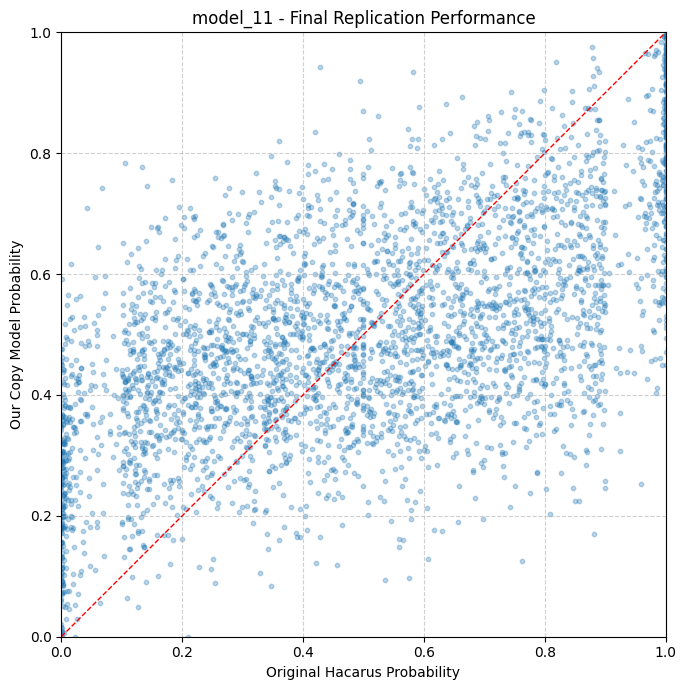

\n==================== model_15 프로세스 시작 ====================
 -> model_15: 학습용(15936개)과 테스트용(3984개)으로 분리 완료.
 -> ⚠️ SMOGN 적용 실패: redefine phi relevance function: all points are 1. 원본 데이터로 학습을 계속합니다.
\n--- 🚀 [4/7] model_15 모델 학습 파이프라인 시작 ---
 -> [탐색 모드] GridSearchCV를 사용한 최적 하이퍼파라미터 탐색을 시작합니다...
Fitting 5 folds for each of 16 candidates, totalling 80 fits
\n--- 📊 최적화 결과 ---
최고 성능 점수 (Negative MAE): -0.2178
최적 하이퍼파라미터: {'colsample_bytree': 0.8, 'gamma': 0, 'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 500, 'reg_alpha': 0, 'reg_lambda': 1, 'subsample': 0.8}
----------------------
✅ 최종 모델, 스케일러, 특징 순서 정보 저장 완료: /content/drive/MyDrive/solder_replication_output_v6/model_15_model.joblib
\n--- 🚀 [검증] model_15 모델 최종 검증 시작 ---
 -> 모델, 스케일러, 특징 이름 로딩 완료.
 -> 3984개 테스트 조각에 대한 일괄 예측 완료.
 -> 예측 결과 종합 및 최종 점수 결정 완료.
\n--- 📊 model_15 최종 검증 결과 ---
  - MAE (평균 절대 오차): 0.2133
  - R² (결정 계수): 0.2397
  - Pearson Correlation: 0.4918


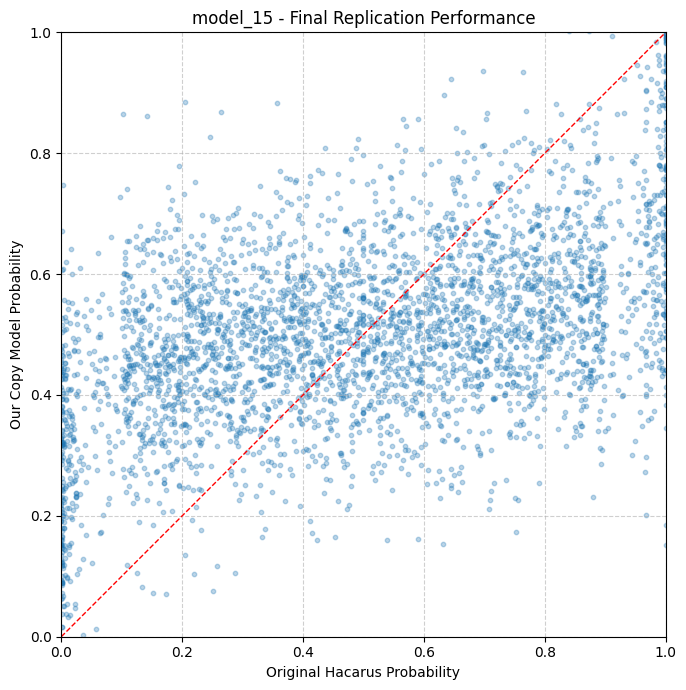

\n--- ✅ 모든 파이프라인 실행 완료 ---


In [11]:
### [7/7] 최종 실행 (v6) ###

# 이 셀을 실행하면 위에서 정의한 main_final 함수가 호출되어
# 전체 파이프라인이 동작합니다.
if __name__ == '__main__':
    main_final()